https://chatgpt.com/c/6a86b8fe-49d8-83eb-abb1-f713a8e8193e

In [ ]:
STEP 1
────────────────────────
Add top10 region statistics
        ↓
STEP 2
────────────────────────
Add 4 calibration objectives
        ↓
    Sharpe
    Calmar
    Return/Risk
    Robust Top-10% Sharpe
        ↓
STEP 3
────────────────────────
Run ALL 4 OOS
        ↓
STEP 4
────────────────────────
Add OOS statistics
        ↓
    return
    volatility
    Sharpe
    Calmar
    drawdown
    excess vs Dow
        ↓
STEP 5
────────────────────────
Add IS → OOS degradation
        ↓
STEP 6
────────────────────────
Analyze point vs region
        ↓
STEP 7
────────────────────────
Analyze threshold stability
        ↓
STEP 8
────────────────────────
Design adaptive two-stage MC
        ↓
STEP 9
────────────────────────
Compare:
    single-stage winner
    single-stage robust
    two-stage winner
    two-stage robust
        ↓
STEP 10
────────────────────────
Choose methodology using 2000–2023
        ↓
FREEZE EVERYTHING
        ↓
STEP 11
────────────────────────
Run completely blind 2024 → present

After finishing with all steps, regarding optimization imrpovment coding, the project should be freezed. To run the code one final time on the complete data and evaluate after 2024. To make an info graph. If the results are good to make a kind of scientific paper; max 3 pdf pages

# During the moving train/test on the validation data set we train to find which strategy (best train mu/sigma, median from top 10, including more metrics,...) and param range is the optimial one. 

# How often an optimized mu/sigma is bigger than index mu/sigma and for which n_components?

python scripts/run_walk_forward_optimization.py

# How are the optimized parameters distributed?

# How to chose the best parameters bevor applying them on the live test data from 2024?

Are the stored results reflecting what was actually run, mean_reverting and so on

Is the mu/sigms of the index benchmark for each out of sample included as well in the results

To check how big are the results in order to decide if to gitignore results/

Skipped 5 components without required data: EK, UTX, KFT, DWDP, WBA
/home/onyxia/work/MPF_Dev/src/strategy.py:291: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

to determine a decisinon workflow for selecting the best parameter combination for each n_component

## Which n_component has the max mu/sigma when using the best params?

# Which strategy is overall better?

# How are the best params envolving over time?

# RAG?

to collect all findings in b&w research paper

In [1]:
import pandas as pd

In [6]:
data = pd.read_parquet("../data/data_df.parquet")
data

,INDEX,AA,AXP,BA,C,CAT,DD,DIS,GE,GM,...,V_Z_excess_ma63,AAPL_Z_excess_ma63,DOW_Z_excess_ma63,RTX_Z_excess_ma63,AMGN_Z_excess_ma63,CRM_Z_excess_ma63,AMZN_Z_excess_ma63,NVDA_Z_excess_ma63,SHW_Z_excess_ma63,GOOGL_Z_excess_ma63
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,11357.509766,97.246407,45.880306,40.187500,397.500000,24.312500,78.979561,29.471687,239.621872,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04,10997.929688,97.696968,44.147945,40.125000,373.125000,24.000000,76.820839,31.198063,230.036987,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05,11122.650391,103.329002,42.962643,42.625000,388.125000,24.562500,79.314537,32.492844,229.637619,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-06,11253.259766,101.977310,43.837940,43.062500,406.875000,25.812500,81.547699,31.198063,232.707779,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-07,11522.559570,101.676941,44.476181,44.312500,405.000000,26.656250,83.371452,30.704813,241.718567,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,37385.968750,33.770000,185.570007,260.440002,50.860001,290.359985,94.807533,91.019997,101.109337,36.020000,...,0.005590,0.045741,-0.100411,-0.047917,-0.018591,0.072362,0.009337,0.007512,0.081671,-0.011172
2023-12-26,37545.328125,33.869999,185.960007,262.790009,51.340000,295.630005,96.037659,90.949997,101.731842,36.130001,...,0.002685,0.042645,-0.095998,-0.043365,-0.022608,0.077266,0.009781,0.009535,0.089770,-0.013002
2023-12-27,37656.519531,34.810001,187.059998,262.100006,51.459999,298.119995,96.564857,90.379997,102.314445,36.080002,...,-0.001092,0.039772,-0.091699,-0.038807,-0.026403,0.082084,0.009067,0.010873,0.098662,-0.016234


In [9]:
df = pd.read_csv("../results/walk_forward_results_5050.csv")

df = pd.read_csv("../results/wf_mean_reversion_cal6_move12_test12_ncomp2-3_20260826_083502_0fda64249664.csv")

In [8]:
return_cols = df.filter(like="excess_return")
return_cols

,sharpe_excess_return,calmar_excess_return,return_risk_excess_return,robust_excess_return
0,0.121359,-0.059804,0.121359,0.009282
1,0.022878,-0.392459,0.022878,-0.160700
2,0.230021,0.108646,0.230021,0.147458
3,0.029552,0.029552,0.029552,-0.059989
4,0.070018,0.070018,0.070018,-0.029435
5,-0.268917,-0.268917,-0.268917,-0.063807
6,-0.073989,-0.073989,-0.073989,-0.069317
7,-0.004440,-0.004440,-0.004440,0.025118
8,-0.136431,-0.136431,-0.184198,-0.184198
9,-0.047707,-0.047707,-0.047707,-0.121999


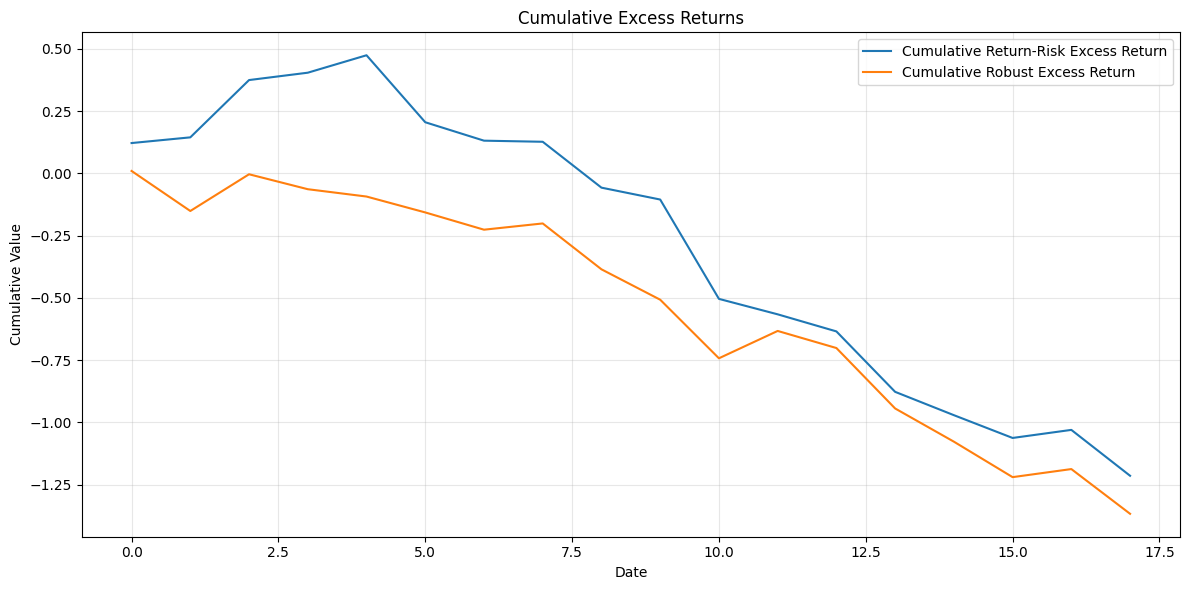

In [9]:
import matplotlib.pyplot as plt

# Assuming df has columns: 'return_risk_excess_return' and 'robust_excess_return'
# and a datetime index (or a date column)

# Calculate cumulative sums
df['cum_return_risk_excess'] = df['return_risk_excess_return'].cumsum()
df['cum_robust_excess'] = df['robust_excess_return'].cumsum()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['cum_return_risk_excess'], label='Cumulative Return-Risk Excess Return')
plt.plot(df.index, df['cum_robust_excess'], label='Cumulative Robust Excess Return')

plt.title('Cumulative Excess Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

https://chatgpt.com/c/6a86b8fe-49d8-83eb-abb1-f713a8e8193e